# 🛒 Retail Sales & Customer Insights Analytics

## Exploratory Data Analysis (EDA)

**Author:** Kavya Choubey

### Objective
This project performs an exploratory data analysis (EDA) on the Superstore retail dataset to uncover business insights related to sales performance, profitability, customer behavior, product performance, regional trends, and discount strategies. The insights generated will support data-driven business decisions and serve as the foundation for an interactive Power BI dashboard.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Chart Style
plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\kavya choubey\OneDrive\Desktop\Retail Sales & Customer Insights Analytics\Python
['.ipynb_checkpoints', 'Retail_EDA.ipynb']


In [4]:
import os

print(os.listdir(".."))

['Dataset', 'Documentation', 'Images', 'PowerBI', 'Python', 'README.md', 'SQL']


In [5]:
import os

print(os.listdir("../Dataset"))

['SuperstoreSales.csv']


In [6]:
# Load Dataset
df = pd.read_csv("../Dataset/SuperstoreSales.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 1. Dataset Overview

## Business Question

Before performing any analysis, it is important to understand the structure and quality of the dataset.

This section answers the following questions:

- How many records are present?
- How many features are available?
- What are the data types?
- Are there missing values?
- Are there duplicate records?

In [14]:
df.shape

(9994, 21)

### Observation

The dataset contains **9,994 rows** and **21 columns**, providing sufficient transactional data for business analysis.

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Insight

- The dataset contains both numerical and categorical features.
- Sales, Profit, Quantity, and Discount are numerical variables.
- Customer, Product, Region, and Category are categorical variables.
- Order Date and Ship Date will be converted into datetime format for time-based analysis.

In [17]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Insight

The statistical summary helps identify the range, average, and distribution of numerical features such as Sales, Profit, Quantity, and Discount.

df.isnull().sum()

### Observation

This step verifies whether the dataset contains missing values that may affect further analysis.

In [18]:
df.duplicated().sum()

np.int64(0)

## Business Objective

To enrich the dataset by creating additional features that simplify time-based analysis and provide deeper business insights.

The new features will help analyze:

- Monthly sales trends
- Quarterly performance
- Shipping efficiency
- Profitability

In [19]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [20]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

# 2. Feature Engineering

## Business Objective

Feature engineering is the process of creating new variables from existing data to make analysis easier and more meaningful.

In this project, new features will be created to support trend analysis, shipping performance evaluation, and profitability analysis.

In [21]:
# Convert object columns into datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [22]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [23]:
# Feature Engineering
# Order Year
df['Order Year'] = df['Order Date'].dt.year

In [24]:
# Month Name
df['Order Month'] = df['Order Date'].dt.month_name()

In [25]:
# Month Number
df['Month No'] = df['Order Date'].dt.month

In [26]:
# Quarter
df['Quarter'] = df['Order Date'].dt.quarter

In [27]:
# Day Name
df['Day Name'] = df['Order Date'].dt.day_name()

In [28]:
# Shipping Days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [29]:
# Profit Margin %
df['Profit Margin %'] = ((df['Profit'] / df['Sales']) * 100).round(2)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


In [30]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Month No,Quarter,Day Name,Shipping Days,Profit Margin %
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,11,4,Tuesday,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,11,4,Tuesday,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,6,2,Sunday,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,10,4,Sunday,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,10,4,Sunday,7,11.25


In [31]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Month No', 'Quarter', 'Day Name', 'Shipping Days',
       'Profit Margin %'],
      dtype='object')

# 3. Executive Dashboard KPIs

## Business Objective

Before performing detailed analysis, business leaders need a quick overview of the company's overall performance.

This section calculates the key performance indicators (KPIs) that help executives understand the health of the business at a glance.

### KPIs Covered

- Total Sales
- Total Profit
- Total Orders
- Total Customers
- Average Order Value
- Average Profit per Order
- Average Shipping Days
- Overall Profit Margin

In [32]:
#How much total revenue has the company generated?
total_sales = df['Sales'].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [33]:
#How much total profit has the company earned?
total_profit = df['Profit'].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [34]:
#How many unique customer orders were placed?
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 5009


In [35]:
#How many unique customers purchased products?
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [36]:
#What is the average revenue generated per customer order?
average_order_value = total_sales / total_orders

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $458.61


In [37]:
#How much profit does each order generate on average?
average_profit = total_profit / total_orders

print(f"Average Profit per Order: ${average_profit:,.2f}")

Average Profit per Order: $57.18


In [38]:
#How long does delivery take on average?
average_shipping_days = df['Shipping Days'].mean()

print(f"Average Shipping Days: {average_shipping_days:.2f}")

Average Shipping Days: 3.96


In [39]:
#What percentage of total sales is converted into profit?
overall_profit_margin = (total_profit / total_sales) * 100

print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

Overall Profit Margin: 12.47%


In [40]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Profit per Order",
        "Average Shipping Days",
        "Overall Profit Margin (%)"
    ],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        total_orders,
        total_customers,
        f"${average_order_value:,.2f}",
        f"${average_profit:.2f}",
        f"{average_shipping_days:.2f} Days",
        f"{overall_profit_margin:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Total Orders,5009
3,Total Customers,793
4,Average Order Value,$458.61
5,Average Profit per Order,$57.18
6,Average Shipping Days,3.96 Days
7,Overall Profit Margin (%),12.47%


# 4. Sales Performance Analysis

## Business Objective

Understanding sales performance over time helps businesses identify seasonal trends, peak sales periods, and business growth patterns.

This section answers the following questions:

- How do sales change over time?
- Which months generate the highest sales?
- Which years perform the best?
- Is profit growing along with sales?

### How do monthly sales vary over time?

Monthly sales analysis helps identify seasonal demand, business growth, and low-performing months that may require marketing efforts.

In [41]:
monthly_sales = (
    df.groupby(['Order Year', 'Month No', 'Order Month'])['Sales']
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Year,Month No,Order Month,Sales
0,2014,1,January,14236.895
1,2014,2,February,4519.892
2,2014,3,March,55691.009
3,2014,4,April,28295.345
4,2014,5,May,23648.287


In [42]:
monthly_sales = monthly_sales.sort_values(
    ['Order Year', 'Month No']
)

In [44]:
monthly_sales['Year-Month'] = (
    monthly_sales['Order Year'].astype(str)
    + "-"
    + monthly_sales['Month No'].astype(str).str.zfill(2)
)

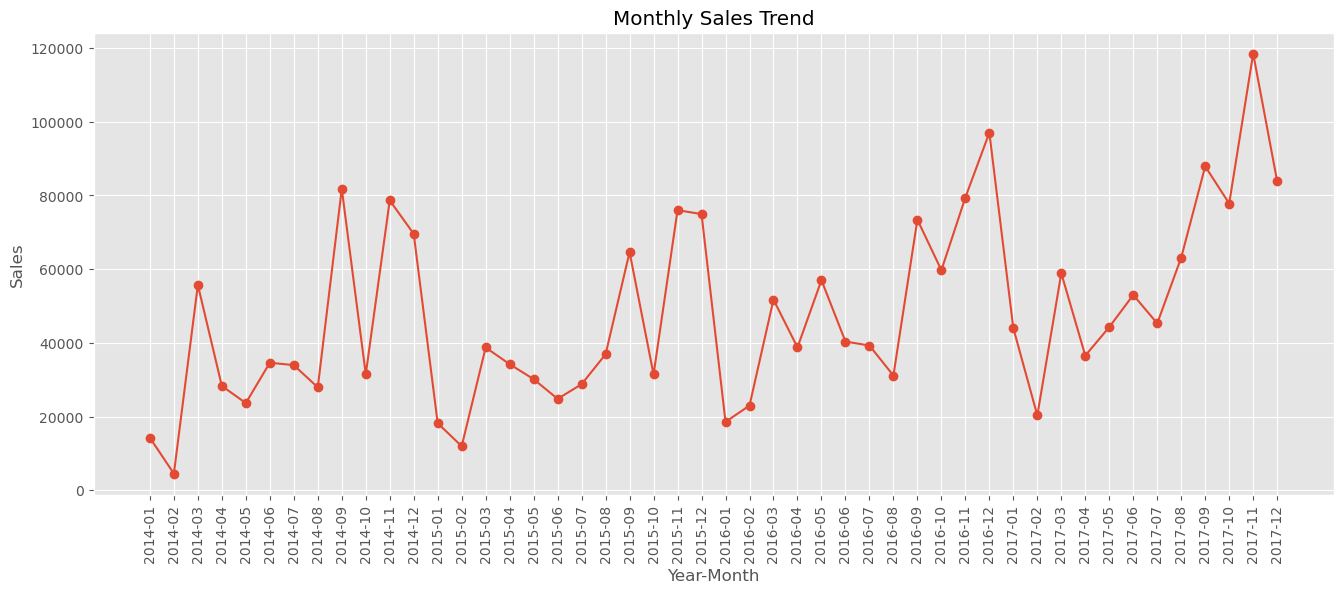

In [45]:
plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Year-Month")

plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

In [46]:
#Which year generated the highest sales?
yearly_sales = (
    df.groupby('Order Year')['Sales']
      .sum()
      .reset_index()
)

yearly_sales

,Order Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


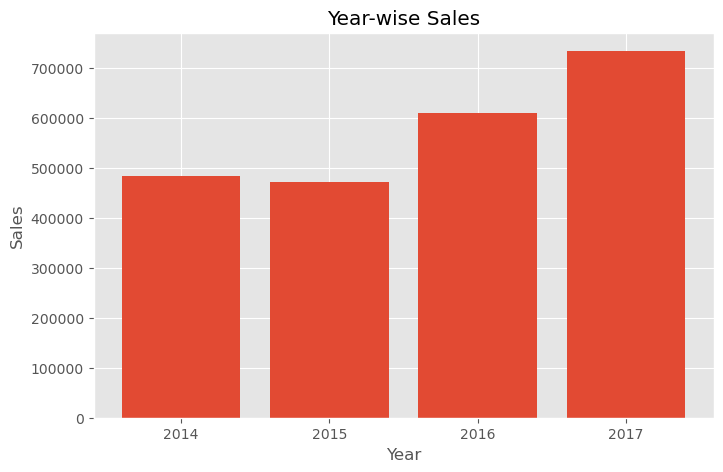

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales['Order Year'].astype(str),
    yearly_sales['Sales']
)

plt.title("Year-wise Sales")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

# 5. Product Performance Analysis

## Business Objective

Products are the core source of business revenue. Analyzing product performance helps identify high-performing categories, profitable products, and areas requiring improvement.

This section answers:

- Which category generates the highest sales?
- Which category earns the highest profit?
- Which sub-category performs best?
- Which products generate the highest revenue?
- Which products generate losses?

In [48]:
#Which product category generates the highest sales?
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


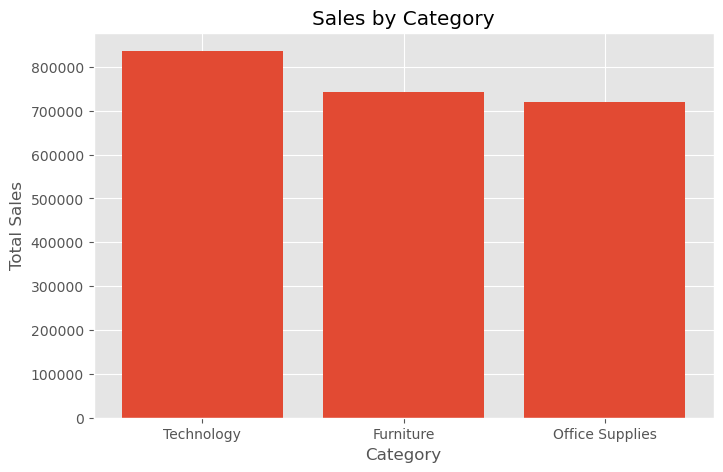

In [49]:
plt.figure(figsize=(8,5))

plt.bar(category_sales['Category'],
        category_sales['Sales'])

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.show()

In [50]:
#Which category generates the highest profit?
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_profit

,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


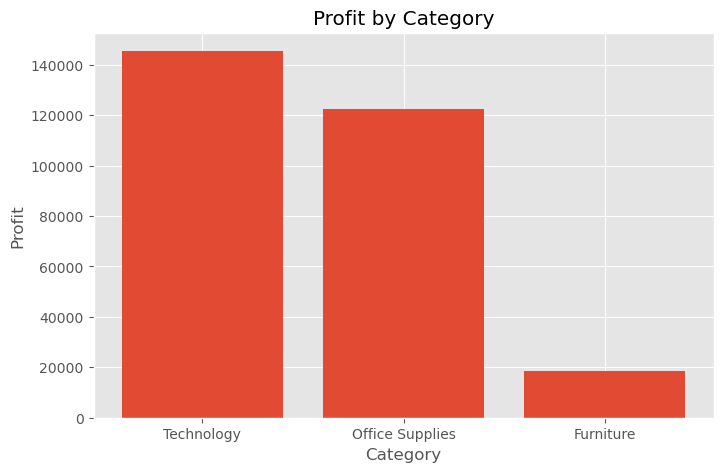

In [51]:
plt.figure(figsize=(8,5))

plt.bar(category_profit['Category'],
        category_profit['Profit'])

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

In [52]:
#Which Sub-Category generates the highest sales?
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

subcategory_sales

,Sub-Category,Sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


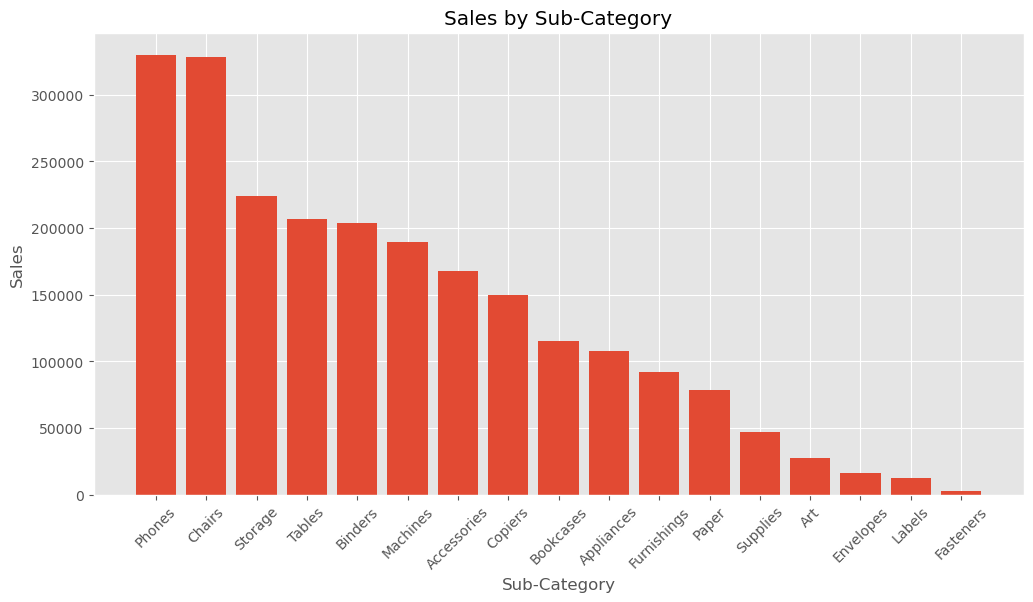

In [53]:
plt.figure(figsize=(12,6))

plt.bar(subcategory_sales['Sub-Category'],
        subcategory_sales['Sales'])

plt.xticks(rotation=45)

plt.title("Sales by Sub-Category")

plt.xlabel("Sub-Category")

plt.ylabel("Sales")

plt.show()

In [54]:
#Top 10 Best-Selling Products
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


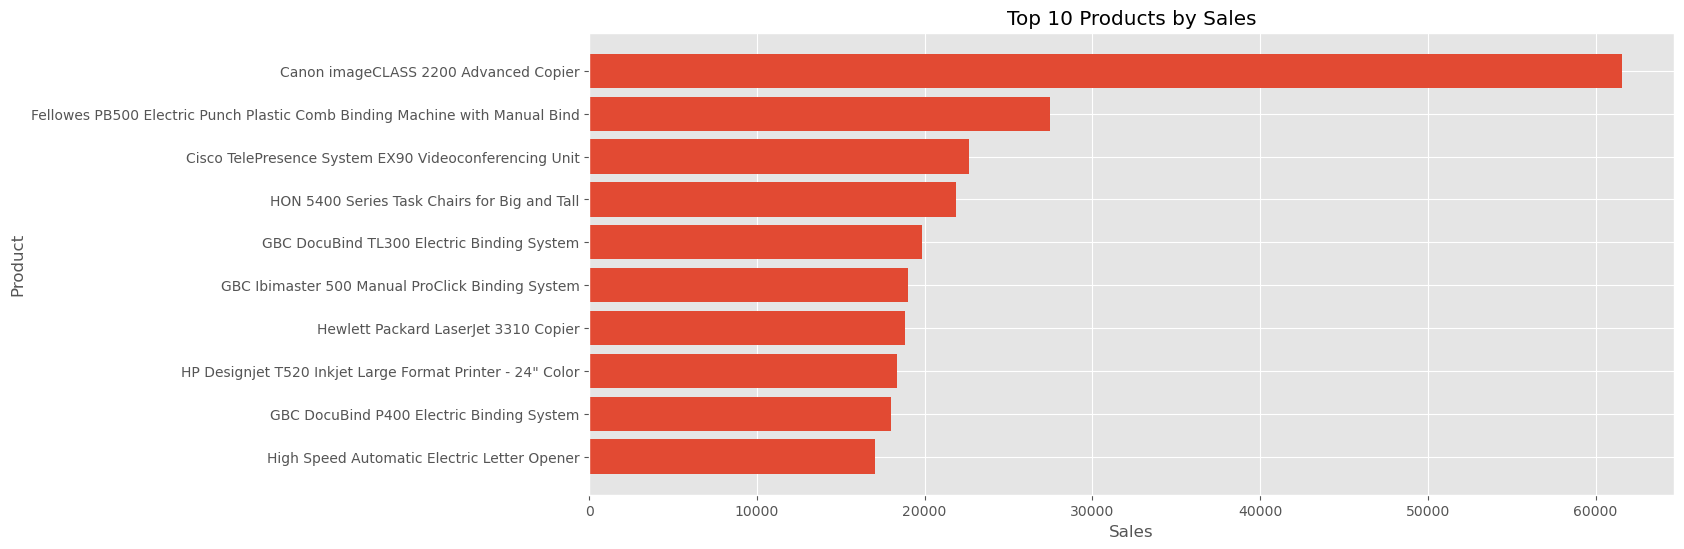

In [55]:
plt.figure(figsize=(14,6))

plt.barh(top_products['Product Name'],
         top_products['Sales'])

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [56]:
#Top 10 Most Profitable Products
top_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_profit_products

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


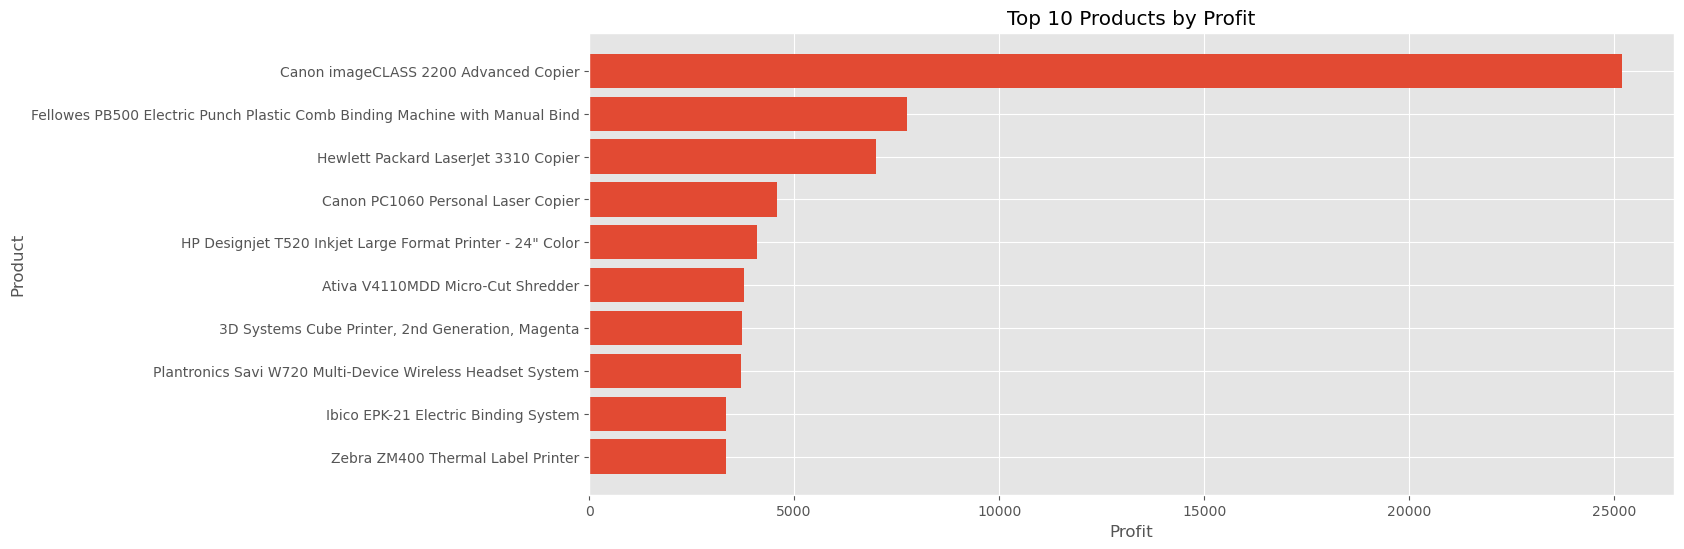

In [57]:
plt.figure(figsize=(14,6))

plt.barh(top_profit_products['Product Name'],
         top_profit_products['Profit'])

plt.title("Top 10 Products by Profit")

plt.xlabel("Profit")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [58]:
#Which products are causing losses?
loss_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
      .reset_index()
)

loss_products

,Product Name,Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


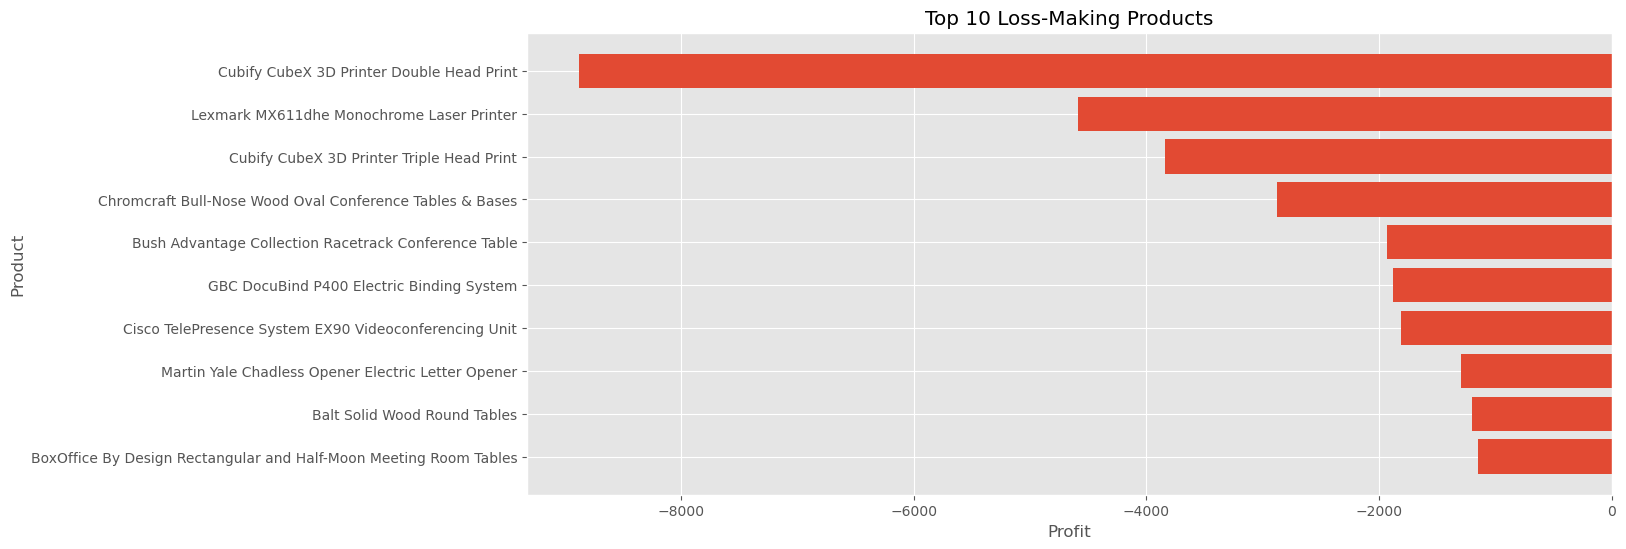

In [59]:
plt.figure(figsize=(14,6))

plt.barh(loss_products['Product Name'],
         loss_products['Profit'])

plt.title("Top 10 Loss-Making Products")

plt.xlabel("Profit")

plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

## Key Findings

- Identified the highest revenue-generating category.
- Compared sales and profitability across categories.
- Analyzed sub-category performance.
- Identified the top-selling products.
- Identified the most profitable products.
- Highlighted products contributing to business losses.

These insights can help management optimize inventory, pricing strategies, and product portfolio decisions.

# 6. Customer & Regional Analysis

## Business Objective

Customers and regions directly influence business growth. Understanding where revenue comes from and which customer segments perform best helps management allocate resources efficiently.

This section answers the following questions:

- Which customer segment generates the highest sales?
- Which region contributes the most revenue?
- Which states generate the highest sales?
- Which cities contribute the highest revenue?
- Who are the top customers by sales?
- 

In [60]:
#Which customer segment generates the highest sales?
segment_sales = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_sales

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


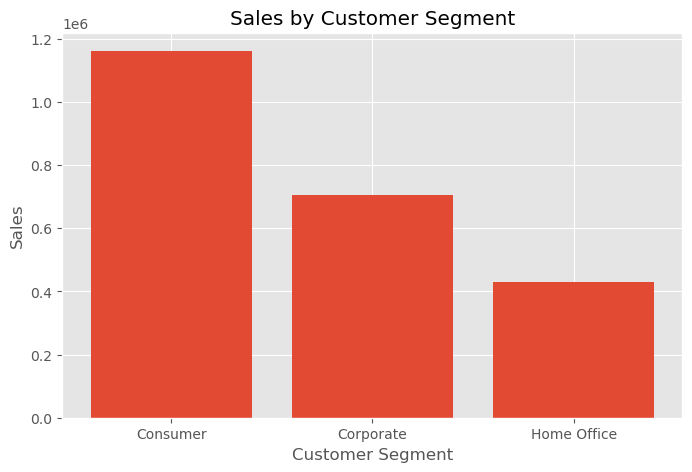

In [61]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales['Segment'],
        segment_sales['Sales'])

plt.title("Sales by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Sales")

plt.show()

In [62]:
#Which region generates the highest sales?
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_sales

,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


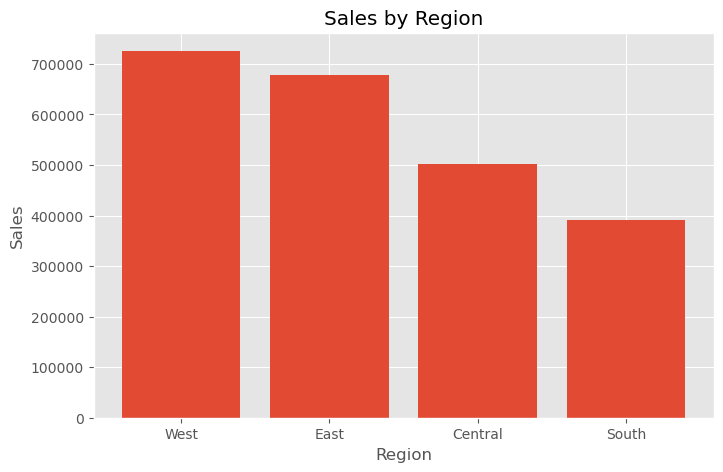

In [63]:
plt.figure(figsize=(8,5))

plt.bar(region_sales['Region'],
        region_sales['Sales'])

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

In [64]:
#Which states generate the highest sales?
top_states = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_states

,State,Sales
0,California,457687.6315
1,New York,310876.2710
2,Texas,170188.0458
3,Washington,138641.2700
4,Pennsylvania,116511.9140
5,Florida,89473.7080
6,Illinois,80166.1010
7,Ohio,78258.1360
8,Michigan,76269.6140
9,Virginia,70636.7200


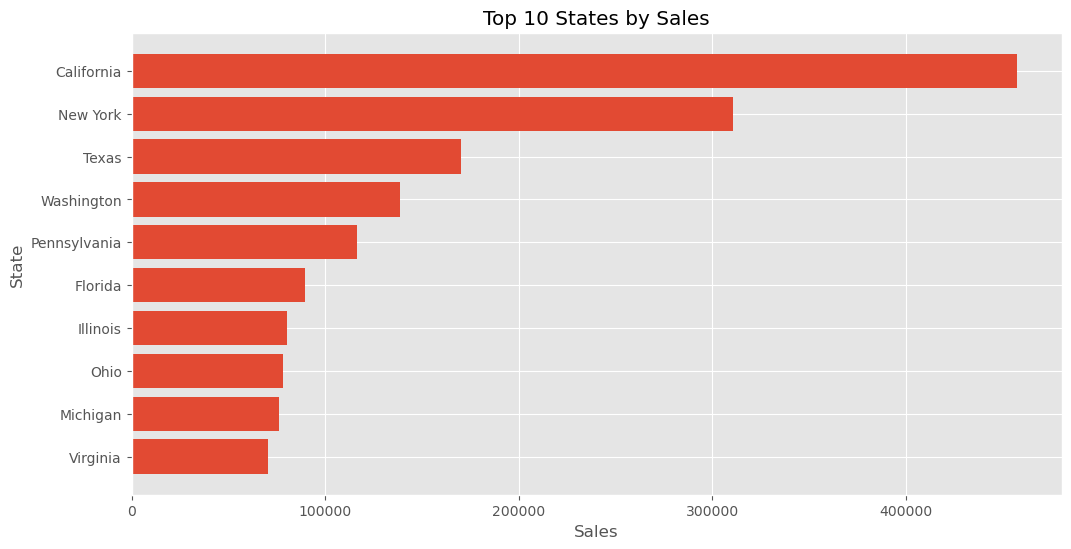

In [65]:
plt.figure(figsize=(12,6))

plt.barh(top_states['State'],
         top_states['Sales'])

plt.title("Top 10 States by Sales")

plt.xlabel("Sales")

plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

In [66]:
#Which cities generate the highest sales?
top_cities = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_cities

,City,Sales
0,New York City,256368.1610
1,Los Angeles,175851.3410
2,Seattle,119540.7420
3,San Francisco,112669.0920
4,Philadelphia,109077.0130
5,Houston,64504.7604
6,Chicago,48539.5410
7,San Diego,47521.0290
8,Jacksonville,44713.1830
9,Springfield,43054.3420


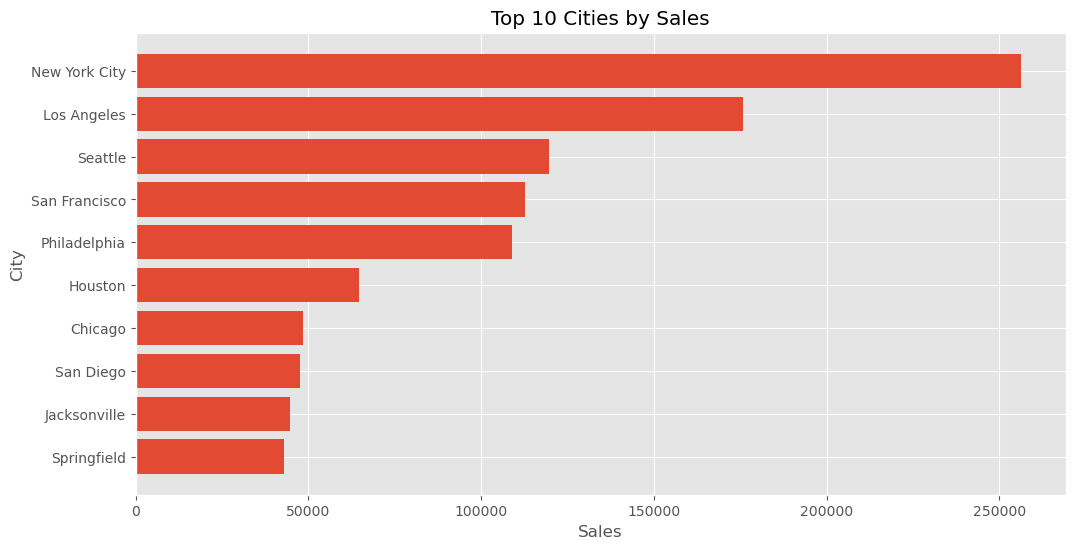

In [67]:
plt.figure(figsize=(12,6))

plt.barh(top_cities['City'],
         top_cities['Sales'])

plt.title("Top 10 Cities by Sales")

plt.xlabel("Sales")

plt.ylabel("City")

plt.gca().invert_yaxis()

plt.show()

In [68]:
#Who are the Top 10 Customers by Sales?
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


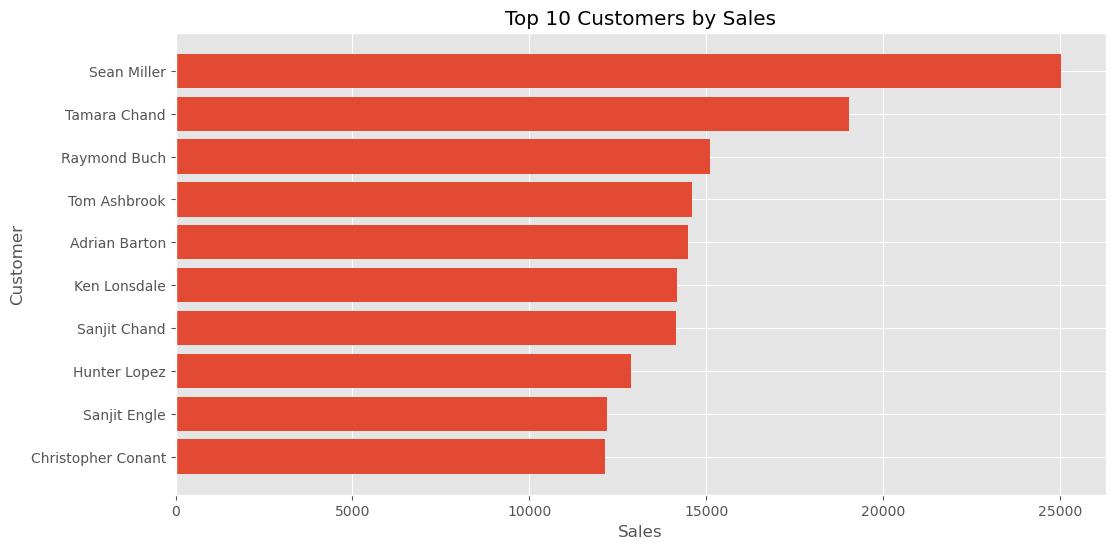

In [69]:
plt.figure(figsize=(12,6))

plt.barh(top_customers['Customer Name'],
         top_customers['Sales'])

plt.title("Top 10 Customers by Sales")

plt.xlabel("Sales")

plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.show()

In [70]:
#Which customer segment is the most profitable?
segment_profit = (
    df.groupby('Segment')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


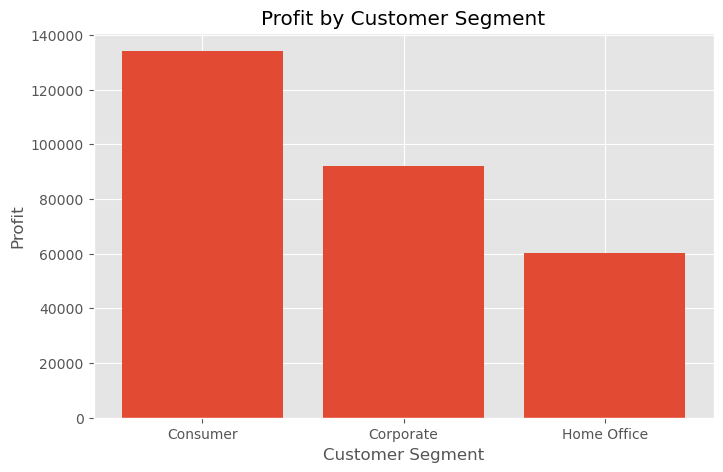

In [71]:
plt.figure(figsize=(8,5))

plt.bar(segment_profit['Segment'],
        segment_profit['Profit'])

plt.title("Profit by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Profit")

plt.show()

## Key Findings

- Identified the highest revenue-generating customer segment.
- Compared regional sales performance.
- Analyzed the top-performing states and cities.
- Identified the most valuable customers.
- Compared profitability across customer segments.

These insights help businesses optimize marketing, customer retention strategies, and regional expansion plans.

# 7. Shipping, Discount & Profitability Analysis

## Business Objective

Efficient shipping, appropriate discount strategies, and healthy profitability are essential for business success.

This section answers:

- Which shipping mode is used the most?
- What is the average delivery time by shipping mode?
- Does higher discount reduce profitability?
- Which discount levels generate losses?
- What is the relationship between Sales and Profit?
- 

In [72]:
#Which Shipping Mode is used the most?
shipping_mode = (
    df.groupby('Ship Mode')['Order ID']
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name='Total Orders')
)

shipping_mode

,Ship Mode,Total Orders
0,Standard Class,2994
1,Second Class,964
2,First Class,787
3,Same Day,264


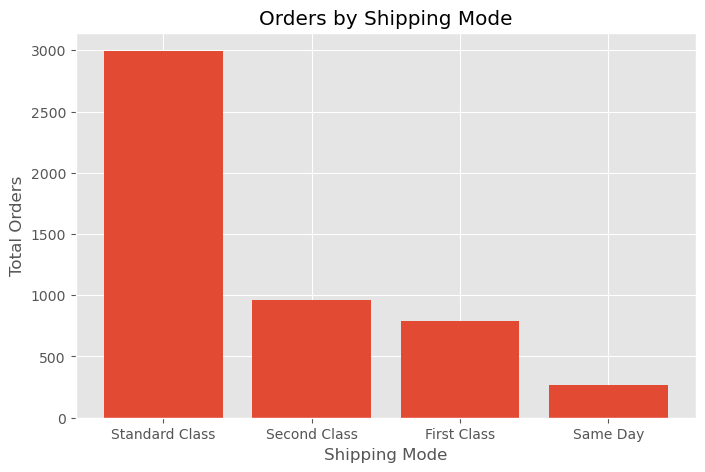

In [73]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_mode['Ship Mode'],
    shipping_mode['Total Orders']
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Orders")

plt.show()

In [74]:
#What is the Average Shipping Time for each Shipping Mode?
shipping_days = (
    df.groupby('Ship Mode')['Shipping Days']
      .mean()
      .sort_values()
      .reset_index()
)

shipping_days

,Ship Mode,Shipping Days
0,Same Day,0.044199
1,First Class,2.182705
2,Second Class,3.238046
3,Standard Class,5.006535


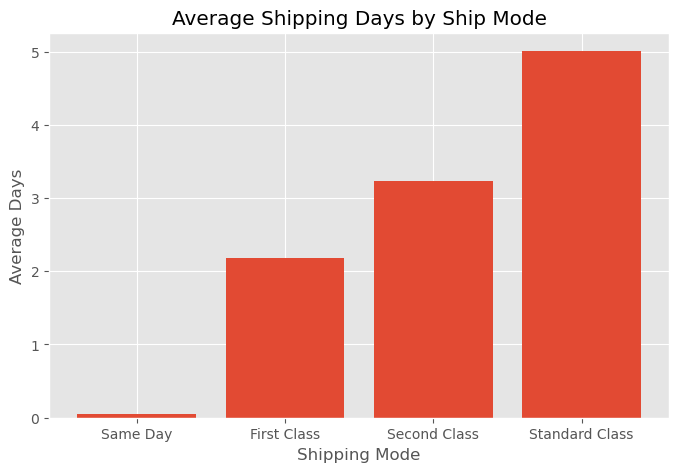

In [75]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_days['Ship Mode'],
    shipping_days['Shipping Days']
)

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Days")

plt.show()

In [76]:
#How does Discount affect Profit?
discount_profit = (
    df.groupby('Discount')['Profit']
      .mean()
      .reset_index()
)

discount_profit

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


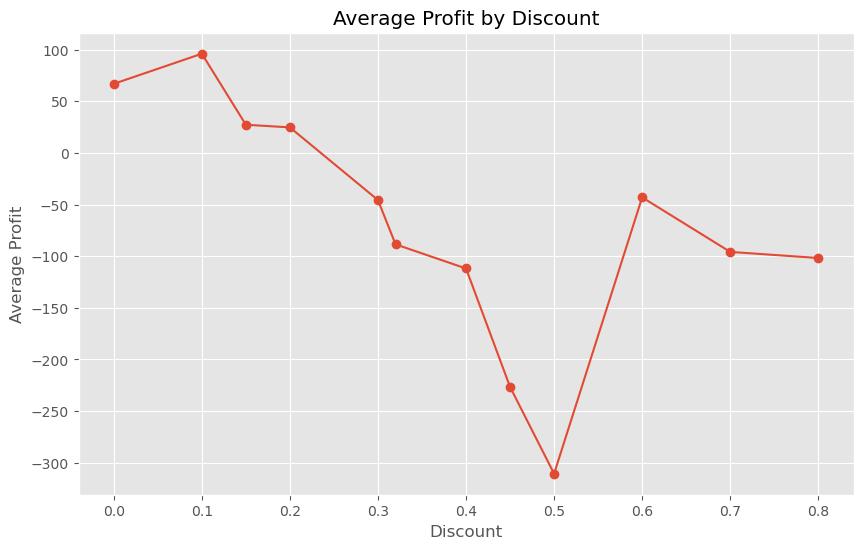

In [77]:
plt.figure(figsize=(10,6))

plt.plot(
    discount_profit['Discount'],
    discount_profit['Profit'],
    marker='o'
)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

In [78]:
#Which Discount Levels Generate the Highest Sales?
discount_sales = (
    df.groupby('Discount')['Sales']
      .sum()
      .reset_index()
)

discount_sales

,Discount,Sales
0,0.00,1.087908e+06
1,0.10,5.436935e+04
2,0.15,2.755852e+04
3,0.20,7.645944e+05
4,0.30,1.032267e+05
5,0.32,1.449346e+04
6,0.40,1.164178e+05
7,0.45,5.484974e+03
8,0.50,5.891854e+04
9,0.60,6.644700e+03


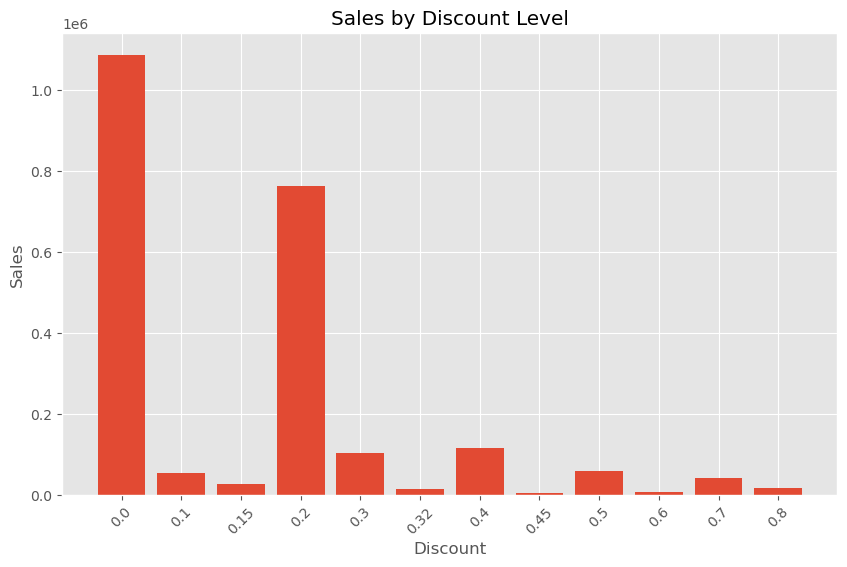

In [79]:
plt.figure(figsize=(10,6))

plt.bar(
    discount_sales['Discount'].astype(str),
    discount_sales['Sales']
)

plt.title("Sales by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

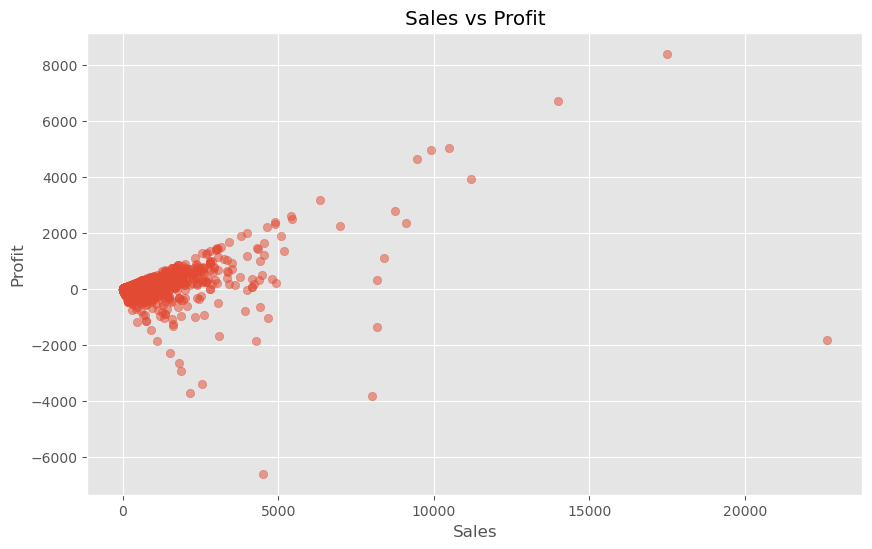

In [80]:
#Relationship between Sales and Profit
plt.figure(figsize=(10,6))

plt.scatter(
    df['Sales'],
    df['Profit'],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

In [81]:
#Which Orders Resulted in a Loss?
loss_orders = (
    df[df['Profit'] < 0]
      .sort_values('Profit')
      [['Order ID',
        'Customer Name',
        'Product Name',
        'Sales',
        'Discount',
        'Profit']]
)

loss_orders.head(10)

,Order ID,Customer Name,Product Name,Sales,Discount,Profit
7772,CA-2016-108196,Cindy Stewart,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
683,US-2017-168116,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
9774,CA-2014-169019,Luke Foster,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
4991,US-2017-122714,Henry Goldwyn,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Natalie Fritzler,Cubify CubeX 3D Printer Double Head Print,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Nathan Cano,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,0.4,-1862.3124
1199,CA-2016-130946,Zuschuss Carroll,GBC DocuBind P400 Electric Binding System,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784


In [82]:
#Top 10 Most Profitable States
state_profit = (
    df.groupby('State')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

state_profit

,State,Profit
0,California,76381.3871
1,New York,74038.5486
2,Washington,33402.6517
3,Michigan,24463.1876
4,Virginia,18597.9504
5,Indiana,18382.9363
6,Georgia,16250.0433
7,Kentucky,11199.6966
8,Minnesota,10823.1874
9,Delaware,9977.3748


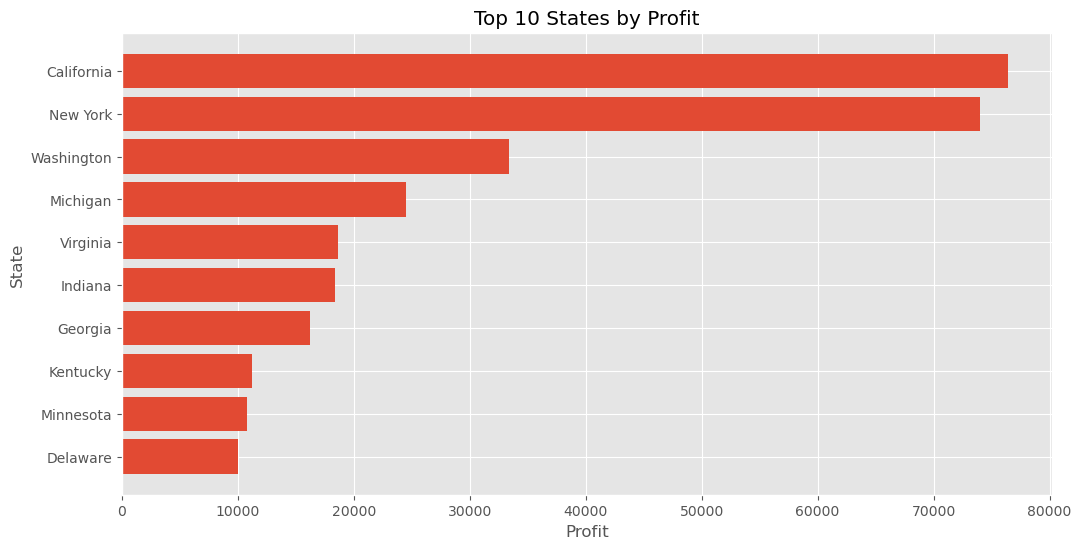

In [83]:
plt.figure(figsize=(12,6))

plt.barh(
    state_profit['State'],
    state_profit['Profit']
)

plt.title("Top 10 States by Profit")
plt.xlabel("Profit")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

## Key Findings

- Identified the most preferred shipping mode.
- Compared delivery performance across shipping methods.
- Evaluated the impact of discounts on profitability.
- Investigated the relationship between sales and profit.
- Identified loss-making orders.
- Highlighted the most profitable states.

These findings help management improve pricing strategies, logistics efficiency, and overall profitability.

# 8. Business Insights & Recommendations

## Executive Summary

Based on the analysis performed on sales, customers, products, regions, shipping, discounts, and profitability, the following business insights and recommendations have been identified.

---

## Key Business Insights

### 1. Technology Category Drives the Highest Revenue
The Technology category contributes significantly to total sales, making it one of the company's strongest business segments.

**Recommendation**
- Increase inventory for high-demand technology products.
- Launch premium product campaigns within this category.

---

### 2. High Sales Do Not Always Mean High Profit

Several high-sales transactions generated low or negative profits due to excessive discounting.

**Recommendation**
- Review discount policies.
- Introduce approval limits for high discounts.
- Monitor profit margins during promotional campaigns.

---

### 3. Customer Segment Performance Varies

Different customer segments contribute differently to revenue and profitability.

**Recommendation**
- Focus marketing efforts on the highest-value customer segment.
- Develop loyalty programs for repeat customers.

---

### 4. Regional Sales Are Uneven

Some regions contribute significantly more revenue than others.

**Recommendation**
- Expand marketing activities in underperforming regions.
- Analyze operational challenges in low-performing markets.

---

### 5. Certain Products Generate Continuous Losses

Some products consistently produce negative profit despite generating sales.

**Recommendation**
- Re-evaluate product pricing.
- Negotiate supplier costs.
- Consider discontinuing consistently loss-making products.

---

### 6. Shipping Performance Can Be Optimized

Different shipping modes have different delivery times.

**Recommendation**
- Improve logistics for slower shipping methods.
- Promote faster shipping options where operationally feasible.

---

### 7. Top Customers Contribute Significant Revenue

A small group of customers contributes a large portion of total sales.

**Recommendation**
- Develop customer retention programs.
- Offer personalized promotions for high-value customers.

---

### 8. Seasonal Sales Trends Exist

Monthly sales analysis indicates seasonal fluctuations in demand.

**Recommendation**
- Increase inventory before peak seasons.
- Launch promotional campaigns during slower months.

# 9. Conclusion

## Project Summary

This project analyzed retail sales data using Python, Pandas, Matplotlib, and Seaborn to identify meaningful business insights.

The analysis included:

- Executive KPI calculation
- Sales trend analysis
- Product performance analysis
- Customer and regional analysis
- Shipping performance analysis
- Discount and profitability analysis

The project demonstrated how data analytics can support business decision-making by identifying high-performing products, valuable customers, profitable regions, and operational improvement opportunities.

The insights generated through this analysis can help management improve pricing strategies, inventory planning, customer retention, logistics, and overall business profitability.